# RECOMMENDATION SYSTEMS - EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 ## Paso 1: Definición del Problema
 1. Predecir si una persona ganará más o menos de 50,000 USD al año
 2. Desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingreso


## Paso 2: Recopilación de Datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv)

[info](https://archive.ics.uci.edu/dataset/2/adult)

In [2]:
df = pd.read_csv('../data/raw/adult-census-income.csv')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## Paso 3: Análisis Descriptivo

In [3]:
df.shape

(32561, 15)

In [4]:
df[(df['workclass'] == '?') & (df['occupation'] == '?')]


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,?,135285,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,?,100820,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df['income'].value_counts() / len(df)

income
<=50K    0.75919
>50K     0.24081
Name: count, dtype: float64

In [8]:
df = df.replace('?', np.nan)

In [9]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [10]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

> ## Observaciones:
>
> - Existen un total de 32561 filas (en este caso, personas) y 15 columnas, entre las cuales esta nuestra variable objetivo `income`
> - La variable objetivo es tipo objeto y tiene 2 clases desbalanceadas: <=50K con un 76% de los datos y >50K con un 24%
> - Existen 6 variables númericas y 9 categóricas
> - Las variables con datos desconocidos (?) son `workclass`, `occupation` y `native.country`, el resto cuentan todas con valor
> - Tenemos 1836 registros que tienen datos desconidos en `workclass` y `occupation`

## Paso 4: Limpieza de datos

In [11]:
df.duplicated().sum()

24

In [12]:
# Valores duplicados, no lo son porque no los podemos identificar con un id o nombre por lo que no los borramos
df[df.duplicated()]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8453,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8645,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
12202,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
15603,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
17344,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
19067,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
20388,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,NaN,<=50K
20507,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
22783,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [13]:
df['education.num'].nunique()

16

In [14]:
df['education'].nunique()

16

In [15]:
df.drop(columns=['fnlwgt','education'], inplace=True)

> ## Observaciones:
>
> - Los 24 registros que defnlwgttecta como duplicados no los podemos eliminar ya que no tenemos la certeza de que lo sean al no tener un identificativo de casa persona (id)
> - Eliminamos las columnas:
> 1. `fnlwgt` - es un peso de muestreo que ni tiene relacion causal con el target y no tiene importancia para nuestro modelo predictivo
> 2. `education` - es redundante, tenemos la misma informacion en la variable `education.num` y ya está factorizada y ordenada es escala creciente

## Paso 5: Análisis de Variables

### Análisis de Variables Univariante - Numericas

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education.num'}>],
       [<Axes: title={'center': 'capital.gain'}>,
        <Axes: title={'center': 'capital.loss'}>],
       [<Axes: title={'center': 'hours.per.week'}>, <Axes: >]],
      dtype=object)

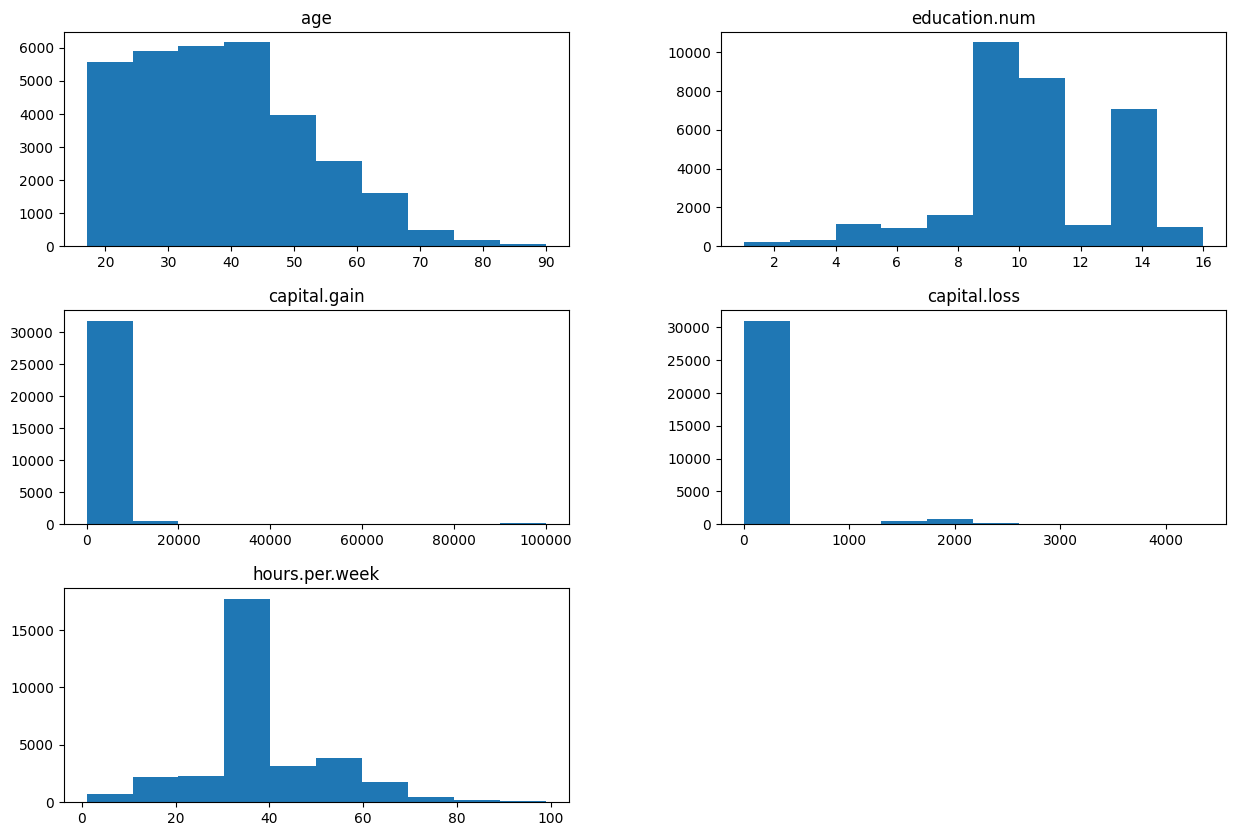

In [16]:
df.hist(figsize=(15, 10), grid=False)

> ## Observaciones:
>
> - La mayoría de personas tienen entre 17 y 45 años
> - Hay más personas con nivel de estudios medio y alto que bajo
> - La mayoría de personas tienen ganancias entre 0 y 10000$
> - La mayoría de personas tienen perdidas entre 0 y 5000$
> - La mayoría de personas trabajan entre 35 y 40 horas semanales

### Análisis de Variables Univariante - Categoricas

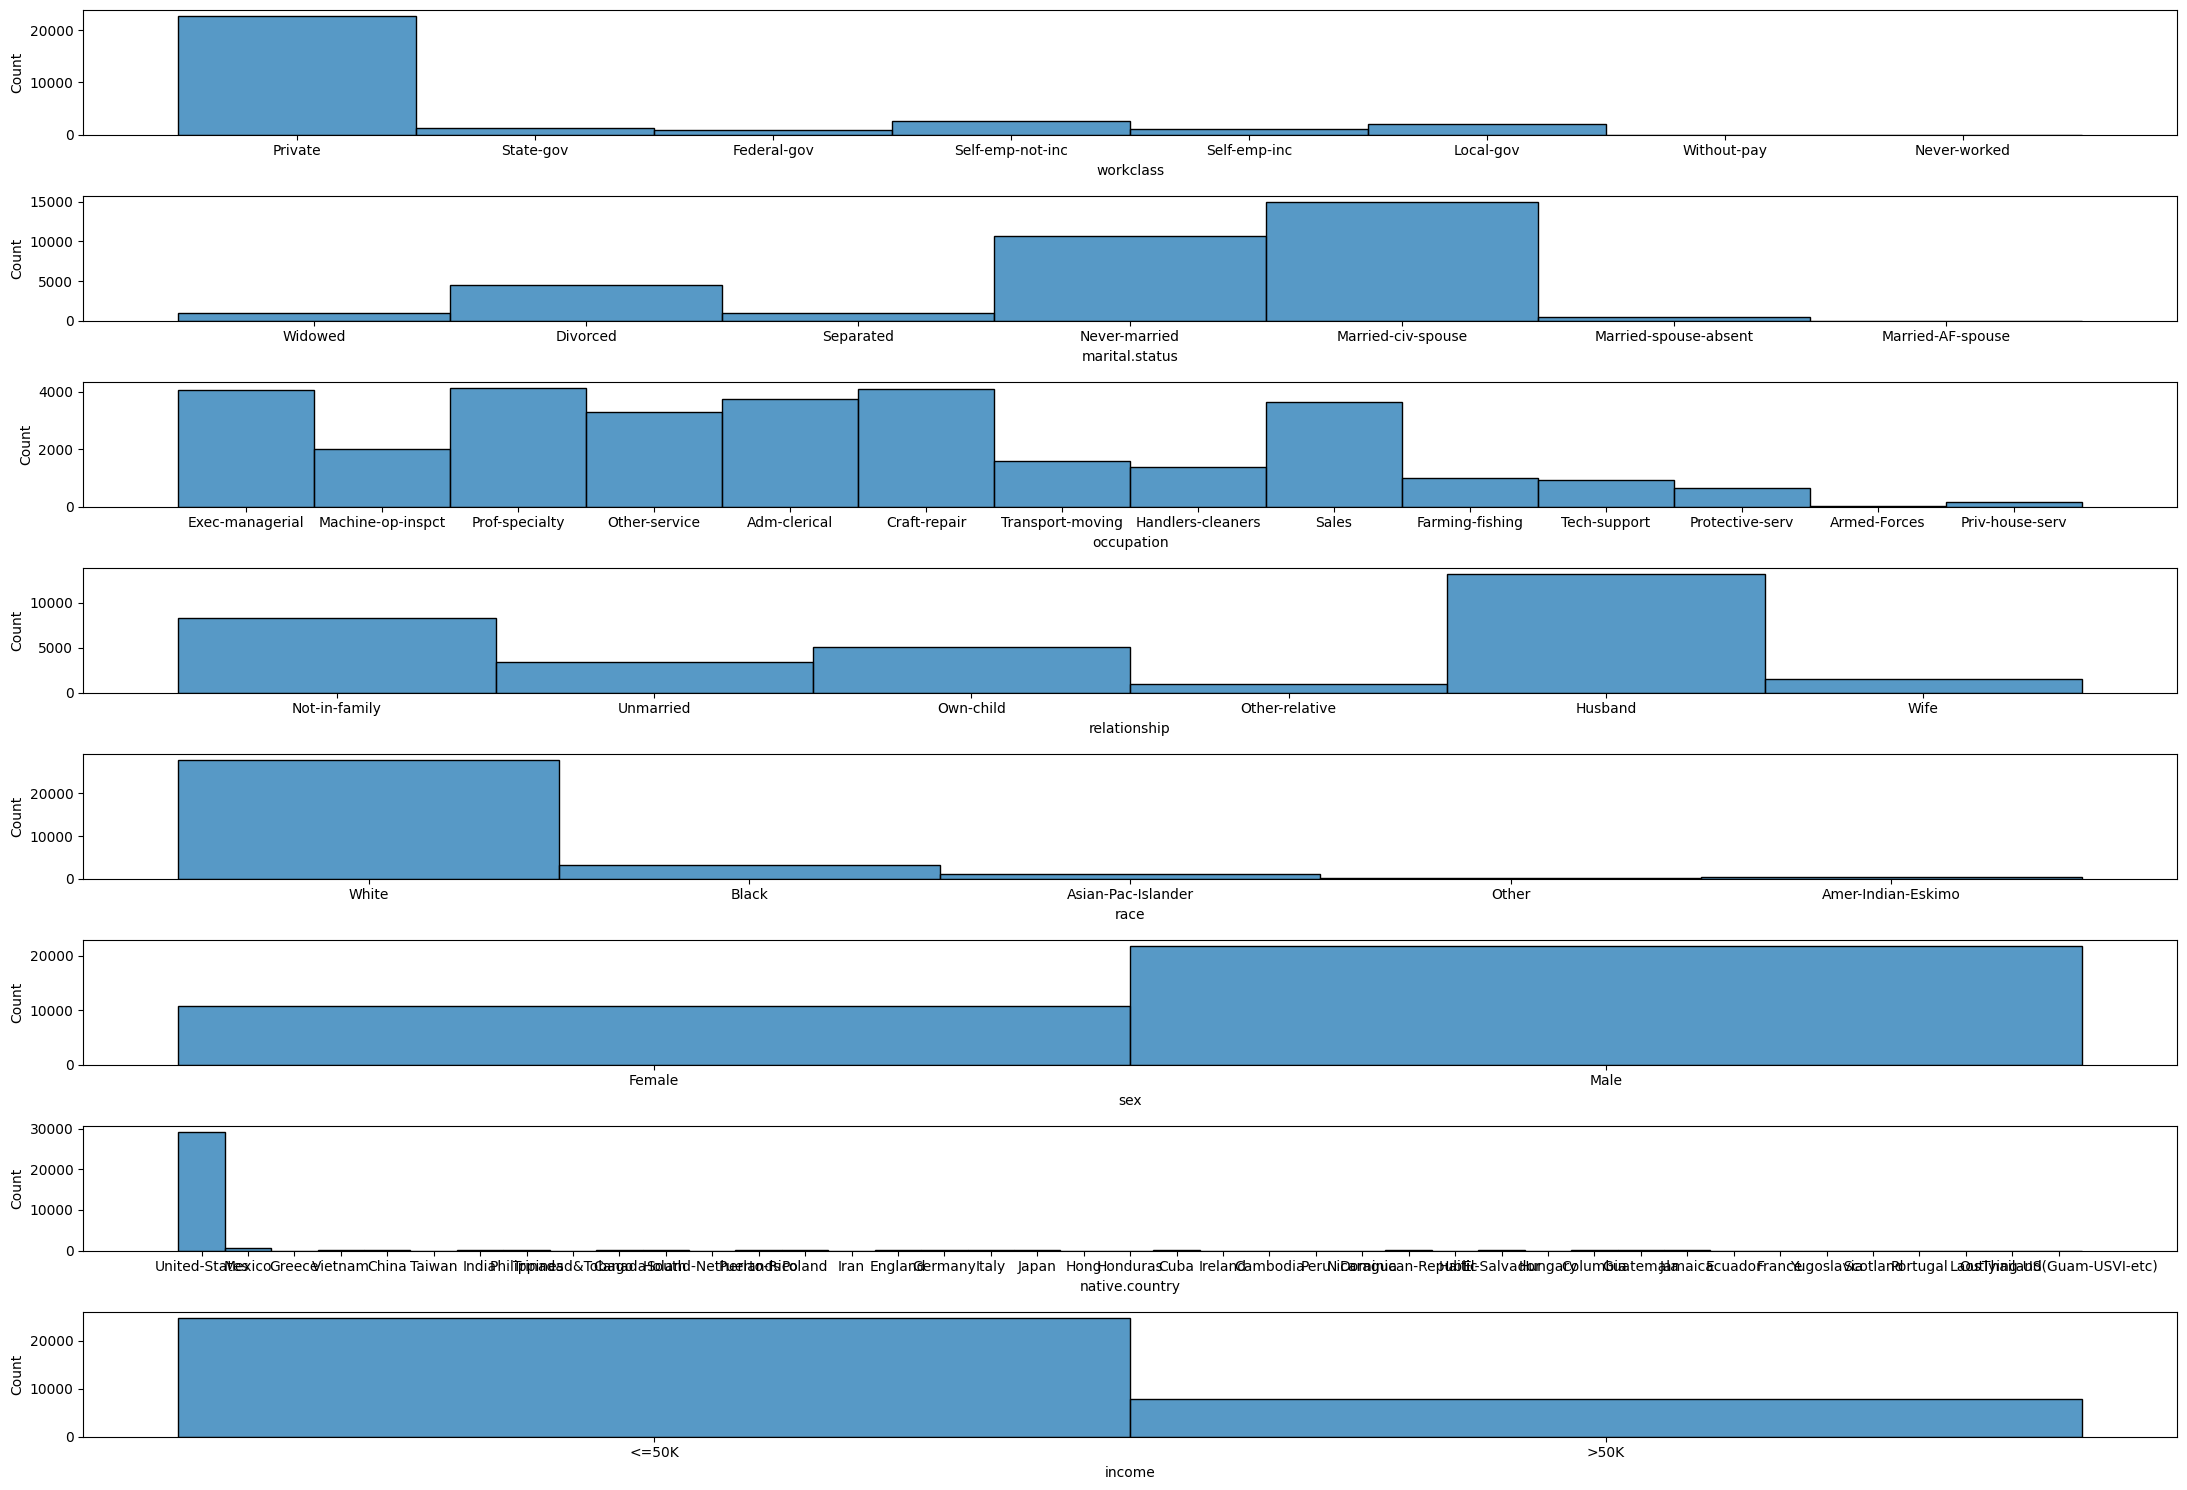

In [17]:
fig, axis = plt.subplots(8, 1, figsize=(22, 15))

sns.histplot(ax=axis[0], data=df, x='workclass')
sns.histplot(ax=axis[1], data=df, x='marital.status')
sns.histplot(ax=axis[2], data=df, x='occupation')
sns.histplot(ax=axis[3], data=df, x='relationship')
sns.histplot(ax=axis[4], data=df, x='race')
sns.histplot(ax=axis[5], data=df, x='sex')
sns.histplot(ax=axis[6], data=df, x='native.country')
sns.histplot(ax=axis[7], data=df, x='income')

plt.tight_layout()

> ## Observaciones:
>
> - La mayoría de personas tienen trabajo privado
> - La mayoría de personas son cónyuge civil casado o que nunca se han casado
> - La mayoría de personas son de raza blanca
> - Existen el doble de hombres que de mujeres

### Análisis de Variables Multivariante : Numéricas - Numéricas

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   education.num   32561 non-null  int64 
 3   marital.status  32561 non-null  object
 4   occupation      30718 non-null  object
 5   relationship    32561 non-null  object
 6   race            32561 non-null  object
 7   sex             32561 non-null  object
 8   capital.gain    32561 non-null  int64 
 9   capital.loss    32561 non-null  int64 
 10  hours.per.week  32561 non-null  int64 
 11  native.country  31978 non-null  object
 12  income          32561 non-null  object
dtypes: int64(5), object(8)
memory usage: 3.2+ MB


In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['age', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

In [20]:
df.columns

Index(['age', 'workclass', 'education.num', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'capital.gain', 'capital.loss',
       'hours.per.week', 'native.country', 'income'],
      dtype='object')

In [21]:
# Convertimos income a binario (<=50K = 0, >50K = 1)
df['income_bin'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
df['income_bin']

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    0
32558    1
32559    0
32560    0
Name: income_bin, Length: 32561, dtype: int64

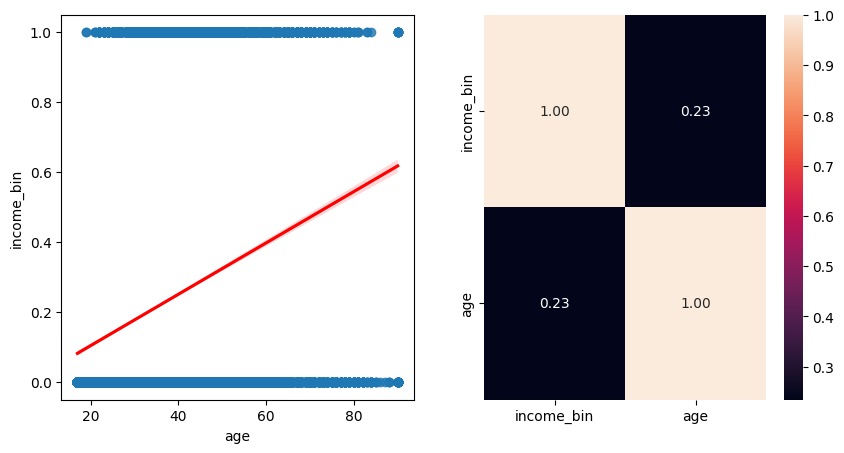

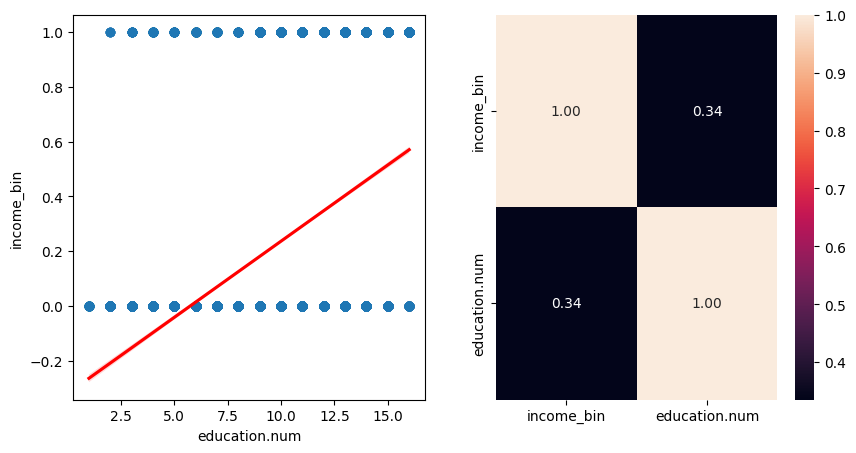

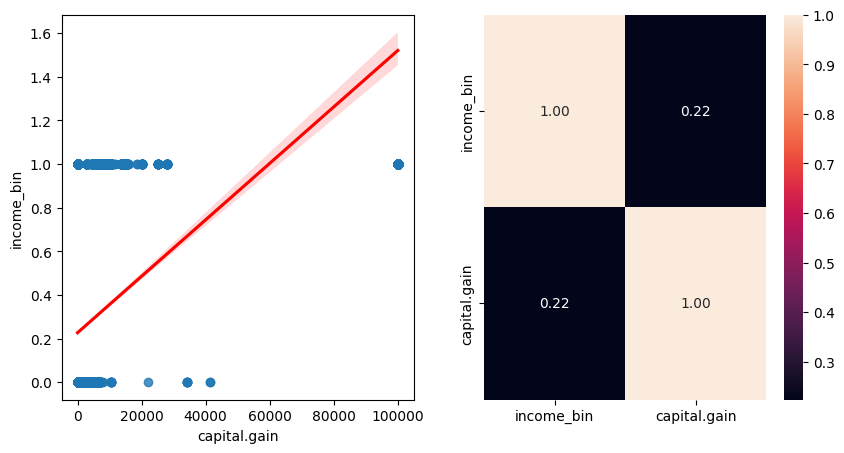

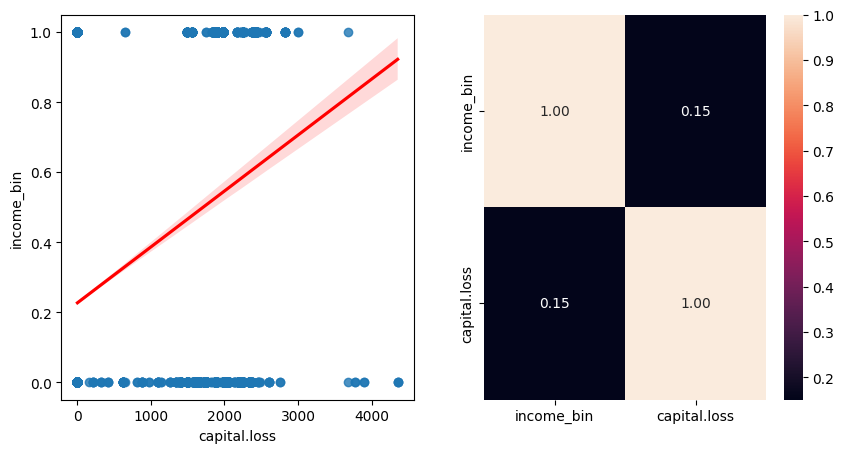

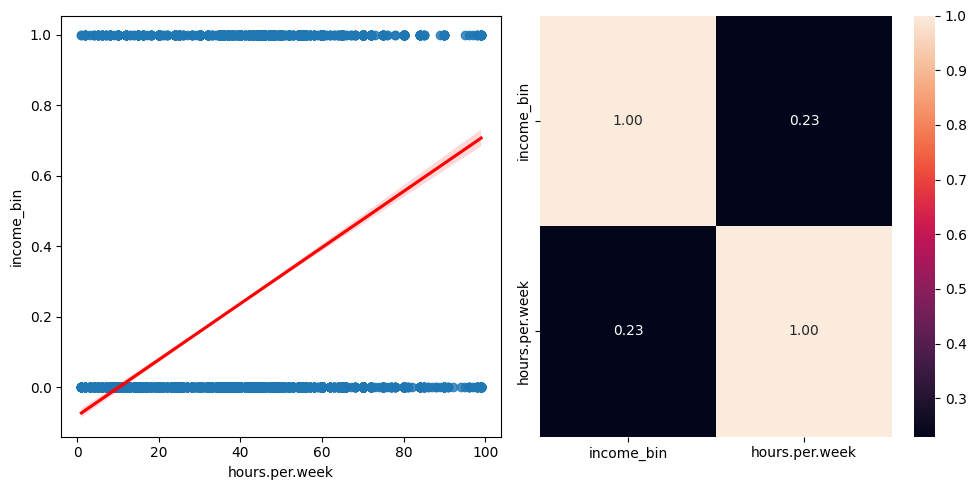

In [22]:
for col in num_cols:
    plt.figure(figsize=(10, 5)) 

    plt.subplot(1, 2, 1) 
    sns.regplot(data=df, x=col, y='income_bin', line_kws={'color': 'red'})

    plt.subplot(1, 2, 2)  
    sns.heatmap(df[['income_bin', col]].corr(), annot=True, fmt='.2f')

plt.tight_layout()

> ## Observaciones:
>
> - La variable numéria que más relacion tiene con el target es `education.num` (0,34), cuanto mayor nivel de estudios más probabilidades de tener ganancias mayores a 50K

### Análisis de Variables Multivariante : Categórico - Categórico

In [23]:
cat_cols = df.select_dtypes(include='object').columns.drop('income') 
cat_cols

Index(['workclass', 'marital.status', 'occupation', 'relationship', 'race',
       'sex', 'native.country'],
      dtype='object')

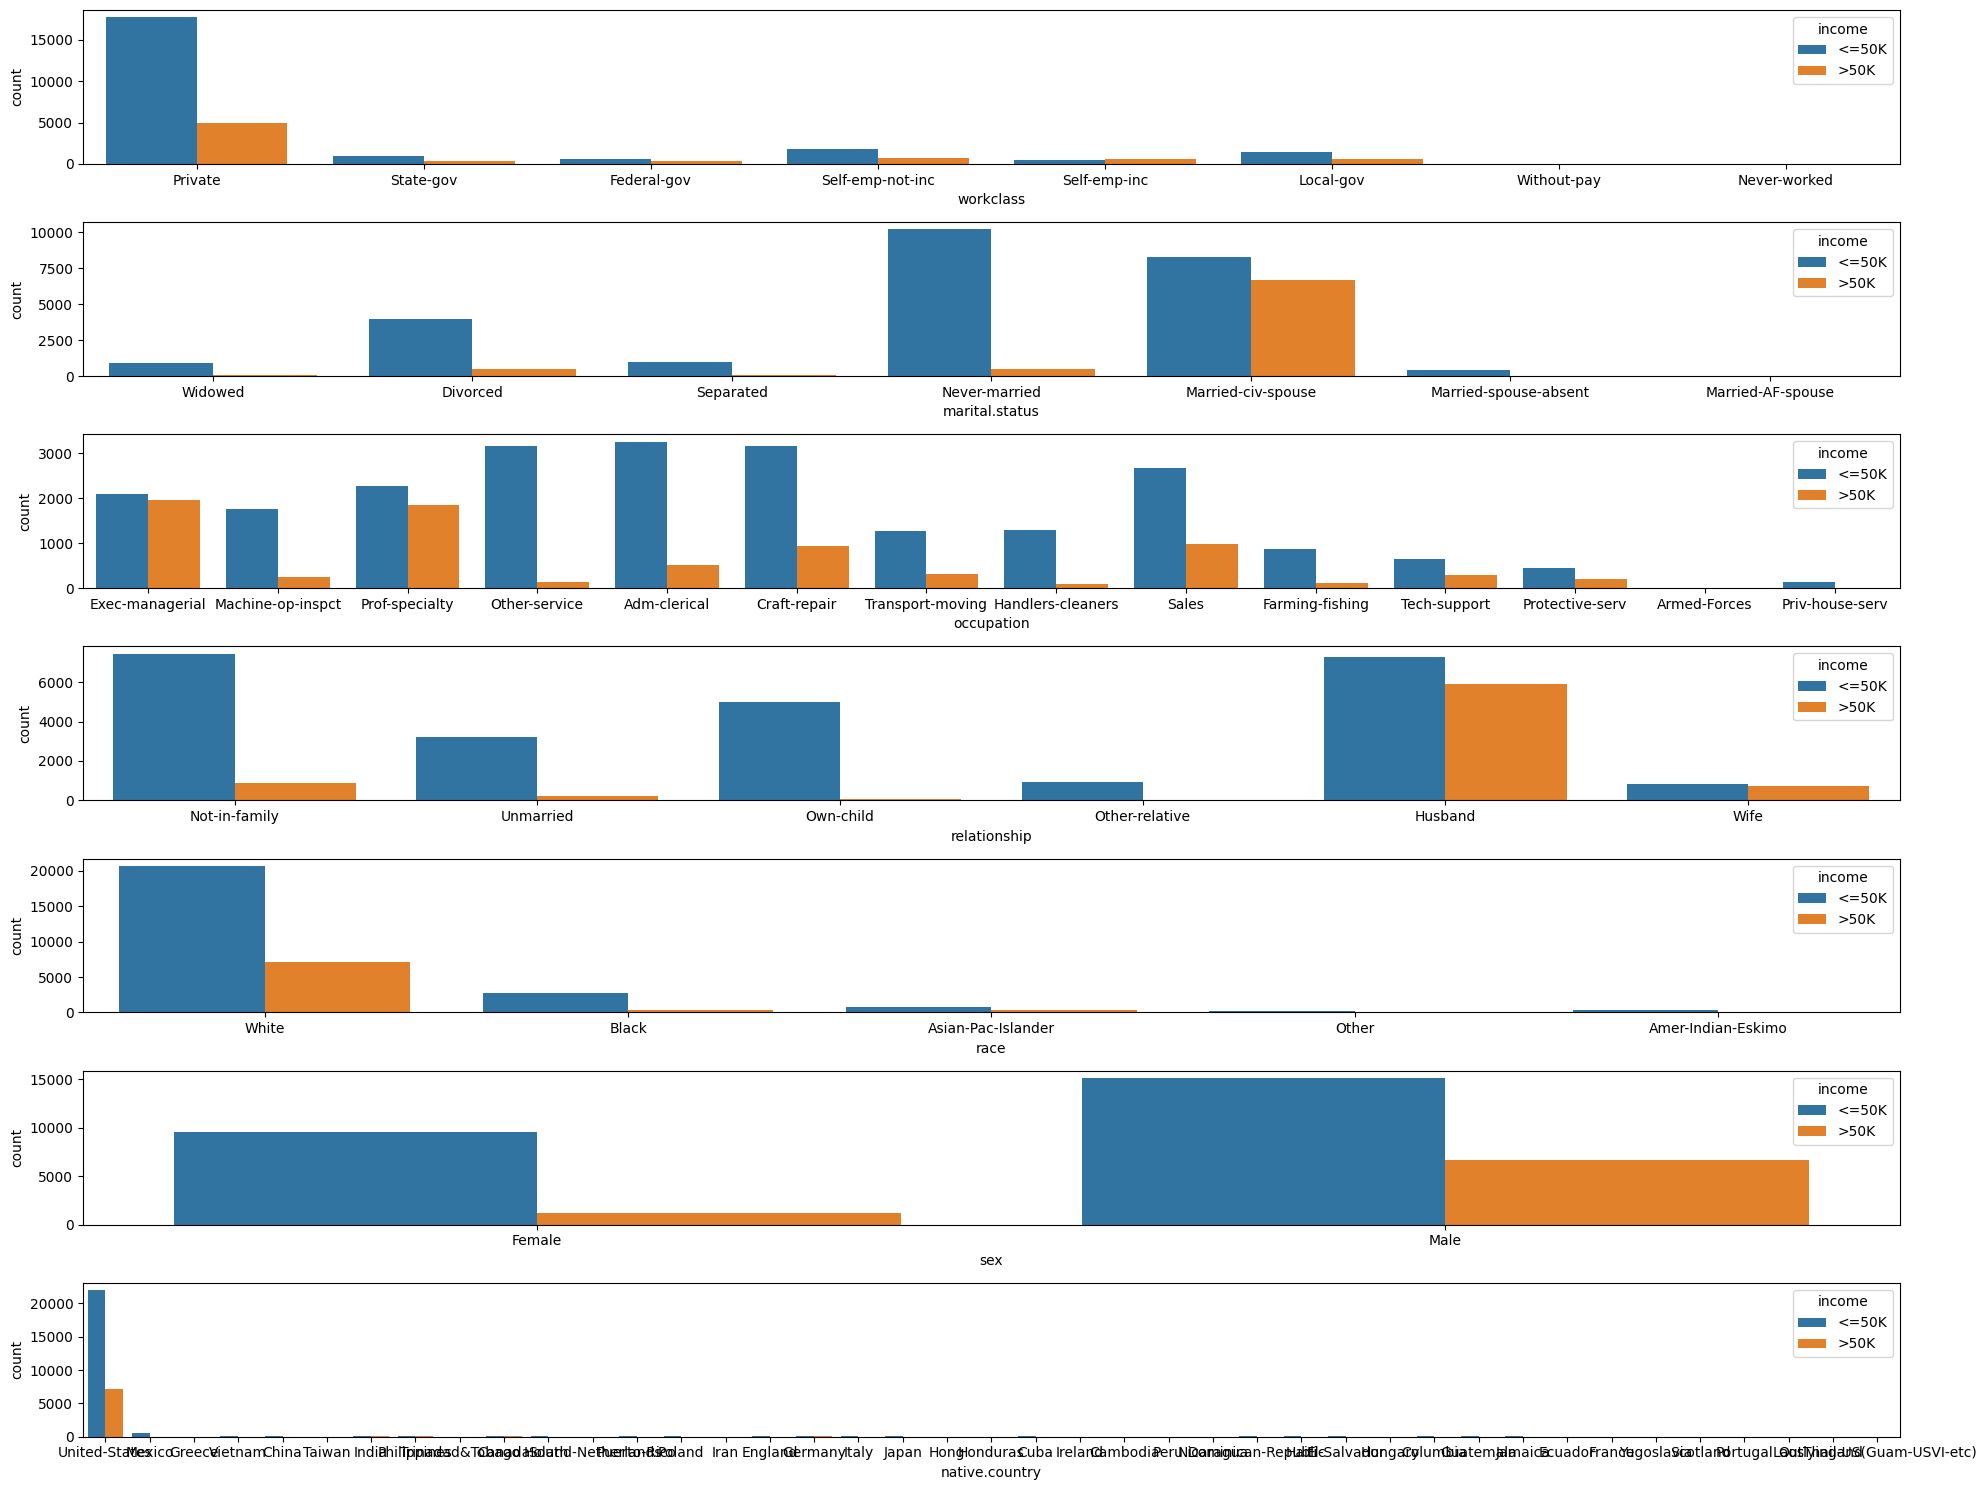

In [24]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(20,15))

for i, col in enumerate(cat_cols):    
    sns.countplot(ax=axes[i], data=df, x=col, hue='income')

plt.tight_layout()

> ## Observaciones:
>
> - Más del triple de personas con trabajo privado tienen ingresos menores a 50k que mayores a 50k
> - Aproximadamente el triple de personas de raza blanca tiene ingresos menores a 50k que mayores a 50k

### Analisis completo: Numérico - Categórico 

In [25]:
df[cat_cols]

,workclass,marital.status,occupation,relationship,race,sex,native.country
0,NaN,Widowed,NaN,Not-in-family,White,Female,United-States
1,Private,Widowed,Exec-managerial,Not-in-family,White,Female,United-States
2,NaN,Widowed,NaN,Unmarried,Black,Female,United-States
3,Private,Divorced,Machine-op-inspct,Unmarried,White,Female,United-States
4,Private,Separated,Prof-specialty,Own-child,White,Female,United-States
...,...,...,...,...,...,...,...
32556,Private,Never-married,Protective-serv,Not-in-family,White,Male,United-States
32557,Private,Married-civ-spouse,Tech-support,Wife,White,Female,United-States
32558,Private,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States
32559,Private,Widowed,Adm-clerical,Unmarried,White,Female,United-States


In [ ]:
# Factorizamos columnas categoricas
for col in cat_cols:
    df[f'{col}_f'] = pd.factorize(df[col])[0]

In [30]:
# Eliminamos las columnas categóricas originales
df.drop(columns=cat_cols, inplace=True)

In [34]:
df.drop(columns=['income'], inplace=True)

In [35]:
df

,age,education.num,capital.gain,capital.loss,hours.per.week,income_bin,workclass_f,marital.status_f,occupation_f,relationship_f,race_f,sex_f,native.country_f
0,90,9,0,4356,40,0,-1,0,-1,0,0,0,0
1,82,9,0,4356,18,0,0,0,0,0,0,0,0
2,66,10,0,4356,40,0,-1,0,-1,1,1,0,0
3,54,4,0,3900,40,0,0,1,1,1,0,0,0
4,41,10,0,3900,40,0,0,2,2,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,10,0,0,40,0,0,3,11,0,0,1,0
32557,27,12,0,0,38,0,0,4,10,5,0,0,0
32558,40,9,0,0,40,1,0,4,1,4,0,1,0
32559,58,9,0,0,40,0,0,0,4,1,0,0,0
